In [4]:
!pip install transformers diffusers lpips
!jupyter nbextension enable --py widgetsnbextension 

  Obtaining dependency information for diffusers from https://files.pythonhosted.org/packages/aa/0b/af1dd4b355accf28fa413d93c3b7df2c25922ebc3435eecc56818a3f8c1e/diffusers-0.25.0-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/53.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/53.8 kB ? eta -:--:--
     -------------------------------------- 53.8/53.8 kB 558.0 kB/s eta 0:00:00
  Obtaining dependency information for huggingface-hub<1.0,>=0.15.1 from https://files.pythonhosted.org/packages/a0/0a/02ac0ae1047d97769003ff4fb8e6717024f3f174a5d13257415aa09e13d9/huggingface_hub-0.20.1-py3-none-any.whl.metadata
  Obtaining dependency information for fsspec>=2023.5.0 from https://files.pythonhosted.org/packages/70/25/fab23259a52ece5670dcb8452e1af34b89e6135ecc17cd4b54b4b479eac6/fsspec-2023.12.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   - -------------------------------------- 0.1/1.8 MB 1.7 MB/

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
s3fs 2023.4.0 requires fsspec==2023.4.0, but you have fsspec 2023.12.2 which is incompatible.
Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: ok


In [5]:
import numpy
from tqdm.auto import tqdm

import torch
from torch import autocast
from torchvision import transforms as tfms

from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import StableDiffusionPipeline

from PIL import Image
from matplotlib import pyplot as plt

# For video display:
from IPython.display import HTML
from base64 import b64encode

# For interactive notebook
import ipywidgets as widgets
from ipywidgets import interact, interact_manual

# Set device - Make sure to set the runtime to GPU in the Kaggle Notebook !
torch_device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch_device)

cpu


In [6]:
# Use the scheduler in stableDiff pipeline
# scheduler = LMSDiscreteScheduler(beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", num_train_timesteps=1000)
stable_diff_pipe = StableDiffusionPipeline.from_pretrained('CompVis/stable-diffusion-v1-4')

stable_diff_pipe.to(torch_device)

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

d:\Anaconda\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\acail\.cache\huggingface\hub\models--CompVis--stable-diffusion-v1-4. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

(…)ature_extractor/preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

safety_checker/config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.25.0",
  "_name_or_path": "CompVis/stable-diffusion-v1-4",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

  0%|          | 0/50 [00:00<?, ?it/s]

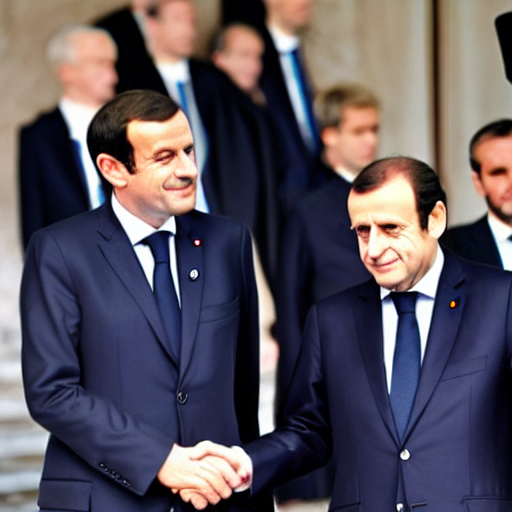

In [9]:
prompt = ['french president']   # Change this and Enjoy !!
guidance_scale = 12.5

# Change the seed parameter to create an original image each time.
generator = torch.manual_seed(69)    # Nice !

# Loop
with autocast("cuda"):
    image = stable_diff_pipe(prompt, guidance_scale = guidance_scale).images[0]
    
# Display the image.
image